# ***Importing Libraries***

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [4]:
df = pd.read_csv("/content/gold_price_data.csv")
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
df.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [6]:
df.shape

(2290, 6)

In [7]:
df.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

In [8]:
df.dtypes

,0
Date,object
SPX,float64
GLD,float64
USO,float64
SLV,float64
EUR/USD,float64


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
 6   Year     2290 non-null   int32         
 7   Month    2290 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(2)
memory usage: 125.4 KB


In [11]:
df.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD,Year,Month
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,2013-03-17 08:23:41.135371008,1654.315776,122.732875,31.842221,20.084997,1.283653,2012.724891,6.329258
min,2008-01-02 00:00:00,676.530029,70.000000,7.960000,8.850000,1.039047,2008.000000,1.000000
25%,2010-08-20 00:00:00,1239.874969,109.725000,14.380000,15.570000,1.171313,2010.000000,3.000000
50%,2013-03-13 12:00:00,1551.434998,120.580002,33.869999,17.268500,1.303297,2013.000000,6.000000
75%,2015-10-25 00:00:00,2073.010070,132.840004,37.827501,22.882500,1.369971,2015.000000,10.000000
max,2018-05-16 00:00:00,2872.870117,184.589996,117.480003,47.259998,1.598798,2018.000000,12.000000
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547,2.993271,3.591149


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()/df.shape[0]*100

,0
Date,0.0
SPX,0.0
GLD,0.0
USO,0.0
SLV,0.0
EUR/USD,0.0
Year,0.0
Month,0.0


In [14]:
(df==0).sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0
Year,0
Month,0


In [15]:
df.corr()

,Date,SPX,GLD,USO,SLV,EUR/USD,Year,Month
Date,1.000000,0.944033,0.209118,-0.782230,-0.174108,-0.794540,0.994957,0.029181
SPX,0.944033,1.000000,0.049345,-0.591573,-0.274055,-0.672017,0.944403,-0.023432
GLD,0.209118,0.049345,1.000000,-0.186360,0.866632,-0.024375,0.206654,0.020494
USO,-0.782230,-0.591573,-0.186360,1.000000,0.167547,0.829317,-0.775765,-0.047335
SLV,-0.174108,-0.274055,0.866632,0.167547,1.000000,0.321631,-0.172485,-0.011976
EUR/USD,-0.794540,-0.672017,-0.024375,0.829317,0.321631,1.000000,-0.791655,-0.012100
Year,0.994957,0.944403,0.206654,-0.775765,-0.172485,-0.791655,1.000000,-0.070903
Month,0.029181,-0.023432,0.020494,-0.047335,-0.011976,-0.012100,-0.070903,1.000000


In [16]:
df.cov()

,Date,SPX,GLD,USO,SLV,EUR/USD,Year,Month
Date,8.885016e+33,4.619306e+19,4.589497e+17,-1.439533e+18,-1.163998e+17,-9.852044e+15,2.807240e+17,9.877995e+15
SPX,4.619306e+19,2.694768e+05,5.964164e+02,-5.995519e+03,-1.009024e+03,-4.589051e+01,1.467453e+03,-4.368159e+01
GLD,4.589497e+17,5.964164e+02,5.421142e+02,-8.471426e+01,1.431144e+02,-7.465862e-02,1.440238e+01,1.713625e+00
USO,-1.439533e+18,-5.995519e+03,-8.471426e+01,3.811677e+02,2.320055e+01,2.129906e+00,-4.533506e+01,-3.318760e+00
SLV,-1.163998e+17,-1.009024e+03,1.431144e+02,2.320055e+01,5.030450e+01,3.000843e-01,-3.661857e+00,-3.050456e-01
EUR/USD,-9.852044e+15,-4.589051e+01,-7.465862e-02,2.129906e+00,3.000843e-01,1.730467e-02,-3.117193e-01,-5.716300e-03
Year,2.807240e+17,1.467453e+03,1.440238e+01,-4.533506e+01,-3.661857e+00,-3.117193e-01,8.959669e+00,-7.621528e-01
Month,9.877995e+15,-4.368159e+01,1.713625e+00,-3.318760e+00,-3.050456e-01,-5.716300e-03,-7.621528e-01,1.289635e+01


In [17]:
df.groupby('Year')[['SPX','GLD','USO','SLV','EUR/USD']].mean()

,SPX,GLD,USO,SLV,EUR/USD
Year,,,,,
2008,1208.337274,86.111148,77.528756,14.760708,1.464481
2009,945.604864,95.834464,34.145446,14.478527,1.393900
2010,1142.600627,119.966397,36.651847,19.922883,1.330050
2011,1268.544188,152.591486,37.781486,34.118063,1.389480
2012,1378.354519,162.151507,35.541598,30.349772,1.287449
2013,1642.193891,136.853213,35.014751,23.179909,1.329559
2014,1930.589375,121.721294,33.887277,18.276295,1.327894
2015,2061.795563,111.165561,16.527623,14.999596,1.109867
2016,2091.121803,118.780634,10.474525,16.161176,1.105778


In [18]:
df.groupby('Month')[['SPX','GLD','USO','SLV']].mean()

,SPX,GLD,USO,SLV
Month,,,,
1,1665.497522,120.580811,31.110901,19.499887
2,1659.508113,123.159434,30.841840,20.221005
3,1680.312963,123.064110,31.637203,20.533513
4,1698.863822,122.074840,33.393138,20.546649
5,1684.848386,122.264102,34.381872,20.112214
6,1614.853899,121.253139,35.669418,19.844552
7,1621.004373,120.656213,36.981716,19.841462
8,1657.507332,127.388727,29.298727,20.909455
9,1615.966303,124.611296,33.346234,20.493519


In [19]:
df.groupby('Year')[['SPX','GLD','USO','SLV']].agg(['max','min'])

SPX                      GLD                     USO             \
              max          min         max         min         max        min   
Year                                                                            
2008  1447.160034   752.440002   99.169998   70.000000  117.480003  29.020000   
2009  1127.780029   676.530029  119.180000   79.790001   41.470001  22.860001   
2010  1259.780029  1027.369995  139.110001  104.040001   42.070000  31.770000   
2011  1361.219971  1099.229980  184.589996  127.930000   45.020000  29.740000   
2012  1461.400024  1277.060059  173.610001  149.460007   42.009998  29.459999   
2013  1848.359985  1457.150024  163.669998  114.820000   39.080002  31.010000   
2014  2090.570068  1741.890015  133.100006  109.790001   39.290001  20.290001   
2015  2130.820068  1867.609985  125.230003  100.500000   20.820000  10.660000   
2016  2271.719971  1829.079956  130.270004  102.889999   12.430000   7.960000   
2017  2690.159912  2257.830078  128.130005  110.470001   12.010000   8.710000   
2018  2872.870117  2581.000000  128.830002  122.543800   14.410000  11.860000   

            SLV             
            max        min  
Year                        
2008  20.621000   8.850000  
2009  18.889999  10.450000  
2010  30.180000  14.750000  
2011  47.259998  26.230000  
2012  35.830002  25.629999  
2013  31.190001  17.889999  
2014  21.180000  14.660000  
2015  17.610001  13.060000  
2016  19.600000  13.170000  
2017  17.530001  14.850000  
2018  16.559999  15.240000

# *Data Visaulization*

<Axes: >

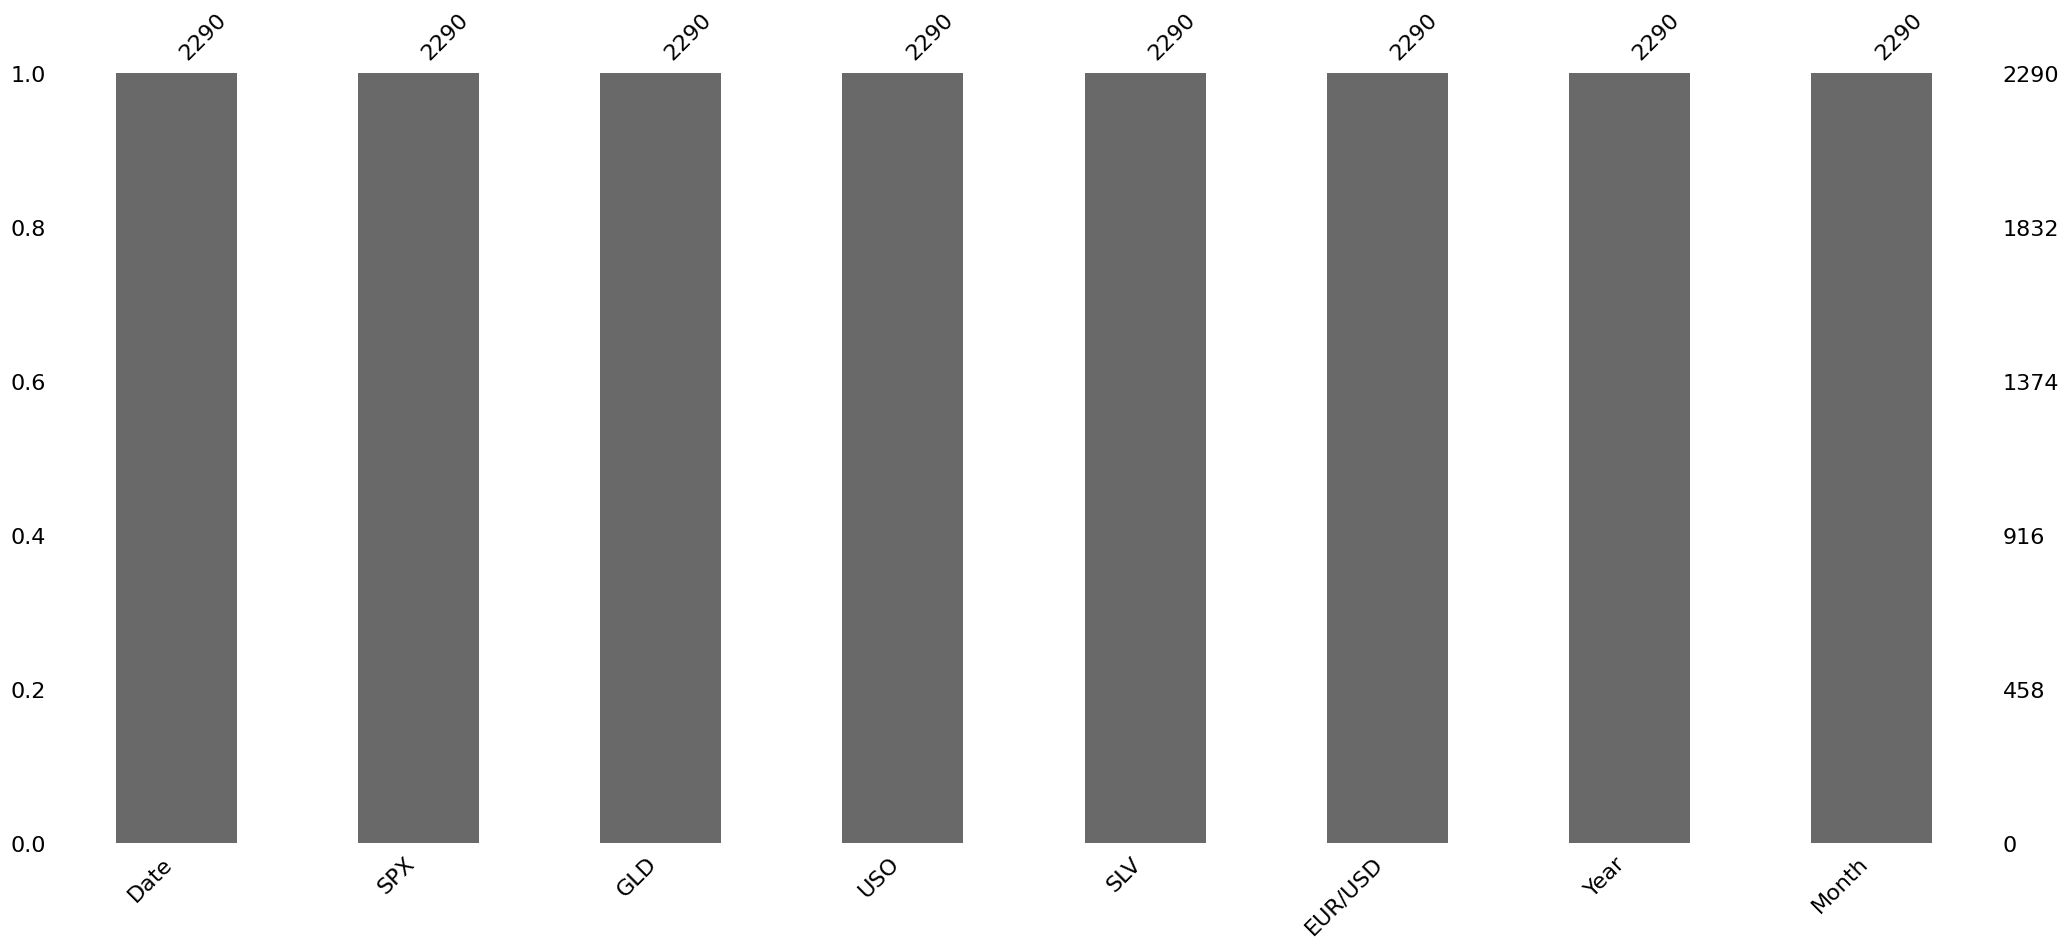

In [20]:
import missingno as msno
msno.bar(df)

<Axes: >

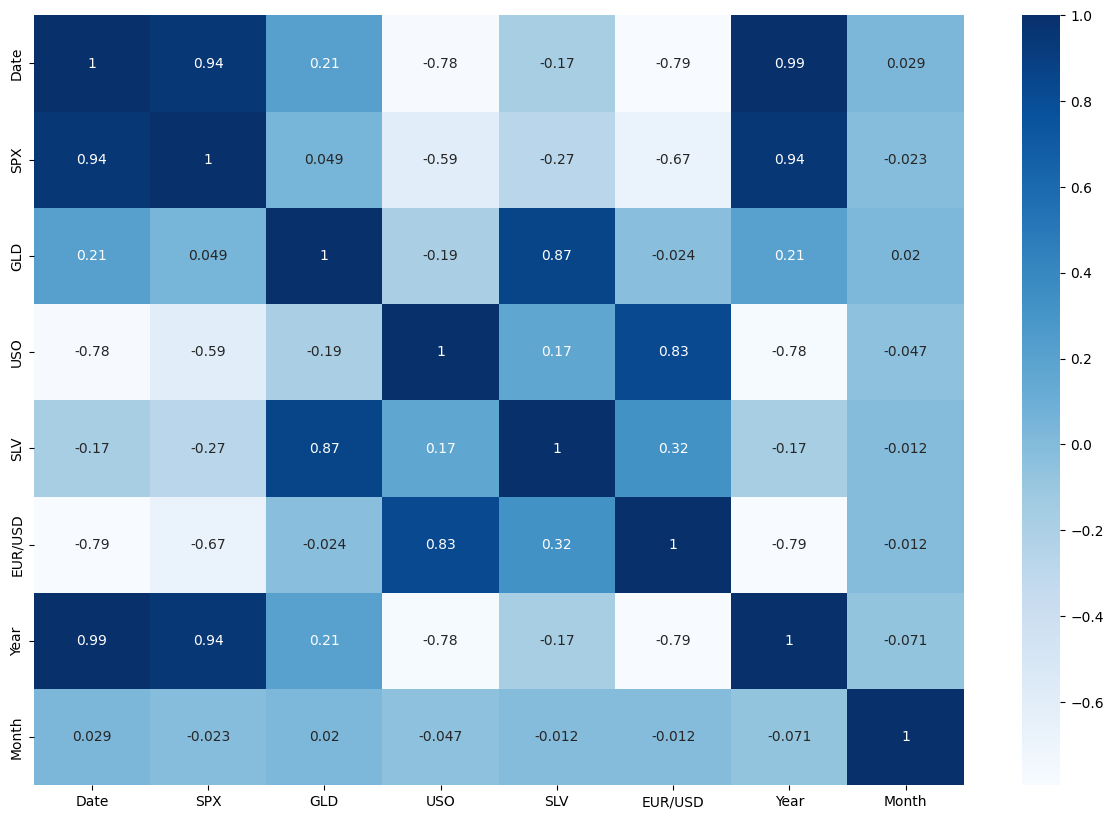

In [21]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,cmap='Blues')

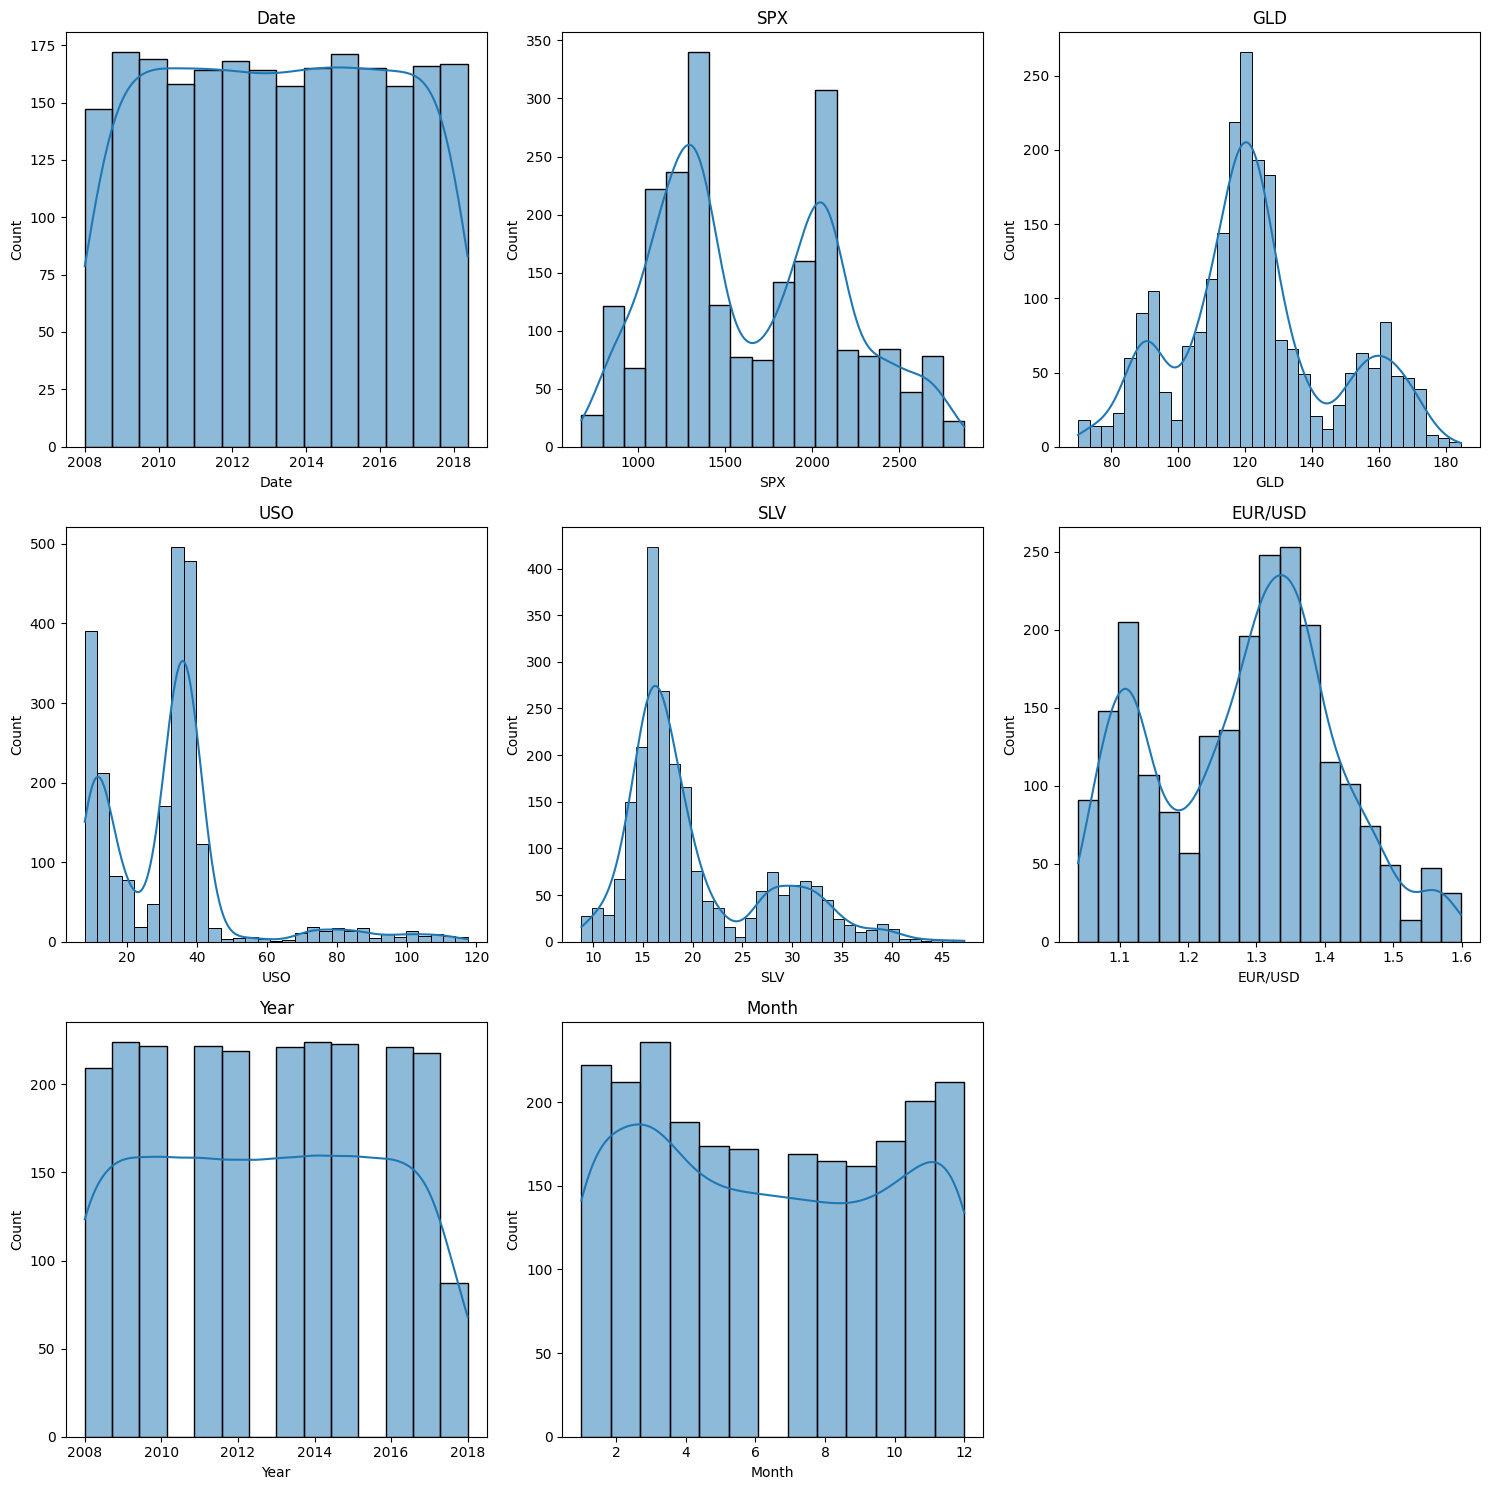

In [22]:
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

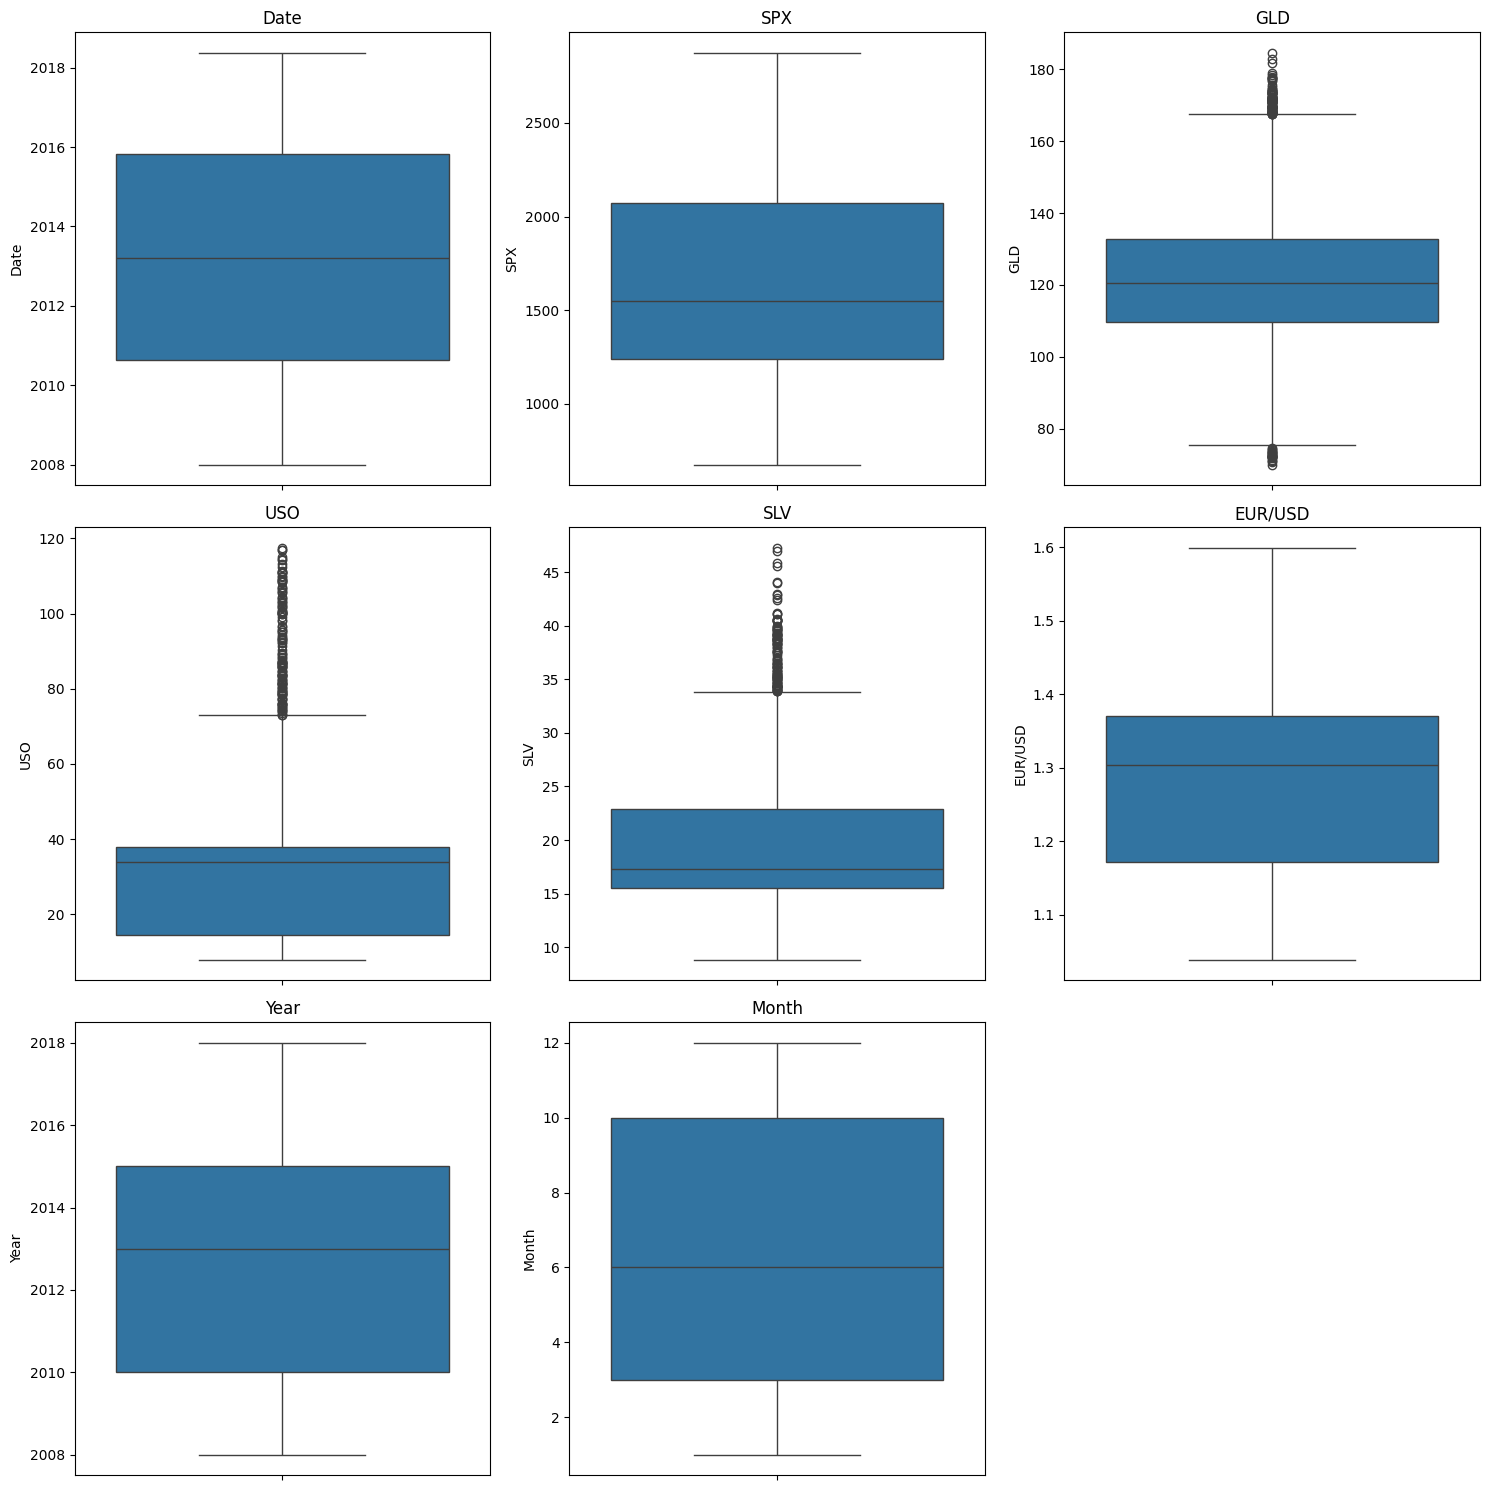

In [23]:
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# ***Data Preprocessing***

In [24]:
for col in df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [25]:
df["USO"] = np.log1p(df["USO"])
df["SLV"] = np.log1p(df["SLV"])

In [26]:
df.drop('Date',axis=1,inplace=True)

In [27]:
df.dropna(inplace=True)

In [28]:
X = df.drop("EUR/USD",axis=1)
y = df["EUR/USD"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ***Training & Predicting***

In [31]:
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "Ridge": {
        "model": Ridge(),
        "params": {"alpha": [0.01, 0.1, 1, 10]}
    },
    "Lasso": {
        "model": Lasso(max_iter=5000),
        "params": {"alpha": [0.001, 0.01, 0.1, 1]}
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {"n_neighbors": [3, 5, 7, 9]}
    },
    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {"max_depth": [None, 5, 10, 20]}
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1]}
    },
    "XGBoost": {
        "model": XGBRegressor(objective='reg:squarederror', verbosity=0),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "max_depth": [3, 6]}
    },
    "LightGBM": {
        "model": LGBMRegressor(),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1]}
    },
    "CatBoost": {
        "model": CatBoostRegressor(verbose=0),
        "params": {"iterations": [200, 500], "learning_rate": [0.01, 0.1], "depth": [4, 6]}
    }
}

In [32]:
results = []

for name, config in models.items():

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "RMSE": rmse,
        "MAE": mae
    });

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1045
[LightGBM] [Info] Number of data points in the train set: 1832, number of used features: 6
[LightGBM] [Info] Start training from score 1.283540


In [33]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Best Params,Train R2,Test R2,RMSE,MAE
0,KNN,{'n_neighbors': 3},0.996402,0.986589,0.015328,0.009115
1,CatBoost,"{'depth': 6, 'iterations': 500, 'learning_rate...",0.996696,0.985607,0.015879,0.010028
2,RandomForest,"{'max_depth': 20, 'n_estimators': 200}",0.998620,0.985286,0.016054,0.009549
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.998452,0.985190,0.016107,0.009588
4,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 200}",0.997057,0.983279,0.017114,0.010339
5,GradientBoosting,"{'learning_rate': 0.1, 'n_estimators': 200}",0.989067,0.978659,0.019335,0.013287
6,DecisionTree,{'max_depth': 20},0.999995,0.968332,0.023553,0.013095
7,LinearRegression,{},0.813607,0.810841,0.057564,0.047174
8,Ridge,{'alpha': 1},0.813596,0.810731,0.057581,0.047185
9,Lasso,{'alpha': 0.001},0.809553,0.803226,0.058711,0.048227


In [37]:
final_model=KNeighborsRegressor(n_neighbors=3)
final_model.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=3)

In [38]:
import joblib

joblib.dump(final_model, 'best_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']